# Zepto Inventory Analysis

In [1]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the data.

import kagglehub

path = kagglehub.dataset_download("palvinder2006/zepto-inventory-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Administrator\.cache\kagglehub\datasets\palvinder2006\zepto-inventory-dataset\versions\2


In [3]:
os.listdir(path)

['zepto_v1.xlsx', 'zepto_v2.csv']

In [4]:
# Load the dataframe.
df = pd.read_csv(os.path.join(path, 'zepto_v2.csv'), encoding='windows-1252')

In [5]:
df.head(2)

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1


In [6]:
df.shape

(3732, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Category                3732 non-null   object
 1   name                    3732 non-null   object
 2   mrp                     3732 non-null   int64 
 3   discountPercent         3732 non-null   int64 
 4   availableQuantity       3732 non-null   int64 
 5   discountedSellingPrice  3732 non-null   int64 
 6   weightInGms             3732 non-null   int64 
 7   outOfStock              3732 non-null   bool  
 8   quantity                3732 non-null   int64 
dtypes: bool(1), int64(6), object(2)
memory usage: 237.0+ KB


In [8]:
df.isnull().sum()

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
dtype: int64

### We can see that the data does not contain any missing or null values.

In [9]:
df.describe(include='all')

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
count,3732,3732,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732,3732.000000
unique,14,1681,NaN,NaN,NaN,NaN,NaN,2,NaN
top,Cooking Essentials,Arden Eggs White,NaN,NaN,NaN,NaN,NaN,False,NaN
freq,514,10,NaN,NaN,NaN,NaN,NaN,3279,NaN
mean,NaN,NaN,15680.117899,7.617095,4.008574,14192.834941,387.843783,NaN,213.270900
std,NaN,NaN,16088.807618,9.211733,2.203511,13850.726265,678.096509,NaN,194.730976
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,NaN,NaN,6000.000000,0.000000,2.000000,5500.000000,100.000000,NaN,50.000000
50%,NaN,NaN,11000.000000,6.000000,5.000000,10400.000000,225.000000,NaN,186.000000
75%,NaN,NaN,20000.000000,10.000000,6.000000,18400.000000,450.000000,NaN,340.000000


## Looks like values in the mrp and the discounted selling price columns are in paise. We need to convert it into rupees.

In [10]:
df['mrp'] = df['mrp']/100

In [11]:
df['discountedSellingPrice'] = df['discountedSellingPrice']/100

In [12]:
df.describe()

,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,quantity
count,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000
mean,156.801179,7.617095,4.008574,141.928349,387.843783,213.270900
std,160.888076,9.211733,2.203511,138.507263,678.096509,194.730976
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,0.000000,2.000000,55.000000,100.000000,50.000000
50%,110.000000,6.000000,5.000000,104.000000,225.000000,186.000000
75%,200.000000,10.000000,6.000000,184.000000,450.000000,340.000000
max,2600.000000,51.000000,6.000000,1399.000000,10000.000000,1500.000000


## Lets check for duplicate values if any

In [13]:
df.duplicated().sum()

np.int64(2)

In [14]:
df[df.duplicated()]

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
2946,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,150.0,10,6,135.0,250,False,250
3290,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,150.0,10,6,135.0,250,False,250


In [15]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['outOfStock'].replace({False:'No', True:'Yes'}, inplace=True)

In [18]:
out_of_stock_percent = round(df.outOfStock.value_counts(normalize=True)*100,0).astype(int)
out_of_stock_percent

outOfStock
No     88
Yes    12
Name: proportion, dtype: int64

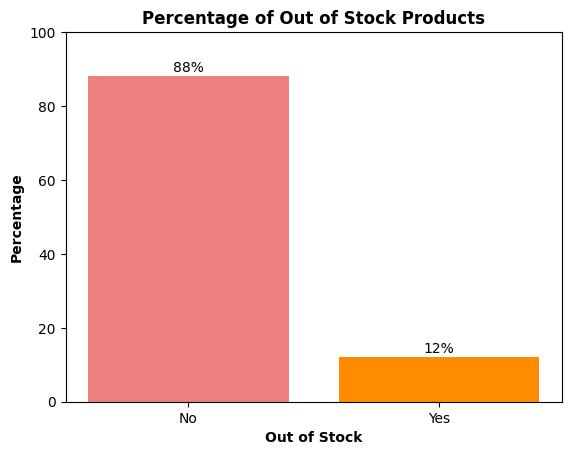

In [21]:
plt.bar(x=out_of_stock_percent.index, height=out_of_stock_percent.values, color=['lightcoral', 'darkorange'])
for i, v in enumerate(out_of_stock_percent):
    plt.text(i, v+0.5, s=f'{v}%', ha='center', va='bottom')
plt.title('Percentage of Out of Stock Products', fontweight='bold')
plt.xlabel('Out of Stock', fontweight='bold')
plt.ylabel('Percentage', fontweight='bold')
plt.ylim(0, 100)
plt.show()

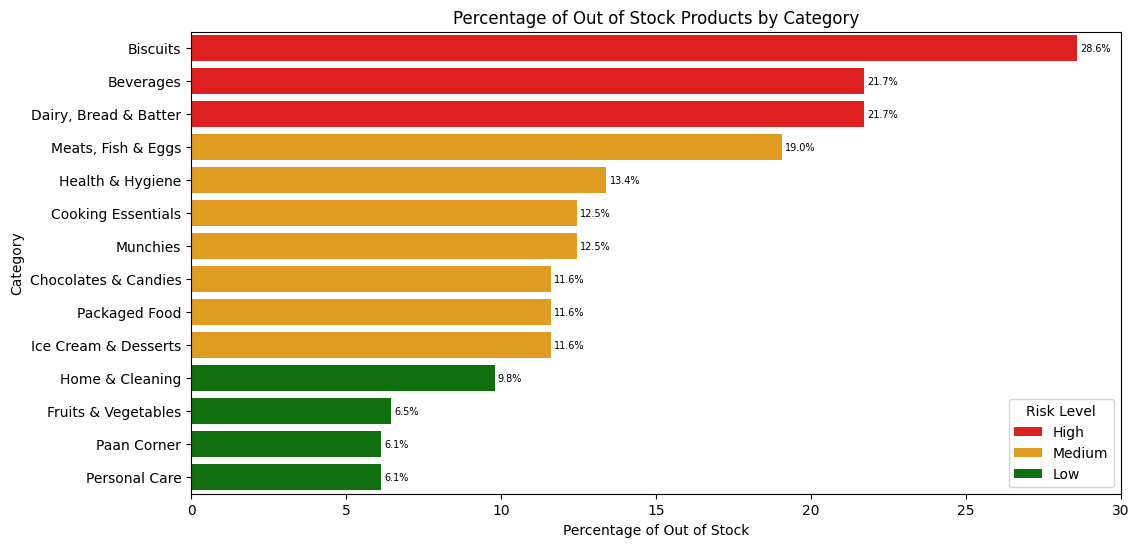

In [ ]:
category_wise_out_of_stock = df.groupby('Category')['outOfStock'].value_counts(normalize=True).unstack().fillna(0)*100
category_wise_out_of_stock = category_wise_out_of_stock.rename(columns={'No':'In Stock', 'Yes':'Out of Stock'})
category_wise_out_of_stock.drop(columns='In Stock', inplace=True)
category_wise_out_of_stock.sort_values(by='Out of Stock', ascending=False, inplace=True)
category_wise_out_of_stock['risk_level'] = category_wise_out_of_stock['Out of Stock'].apply(
                                lambda x: 'High' if x > 20 else ('Medium' if x > 10 else 'Low'))

plt.figure(figsize=(12,6))
sns.barplot(y=category_wise_out_of_stock.index, x=category_wise_out_of_stock['Out of Stock'], 
                    hue=category_wise_out_of_stock['risk_level'], palette={'High':'red', 'Medium':'orange', 'Low':'green'})
plt.title('Percentage of Out of Stock Products by Category')
plt.xlabel('Percentage of Out of Stock')
plt.ylabel('Category')
plt.legend(title='Risk Level')
for i, v in enumerate(category_wise_out_of_stock['Out of Stock']):
    plt.text(v+0.1, i, s=f'{v:.1f}%', va='center',fontsize=7)
plt.show()

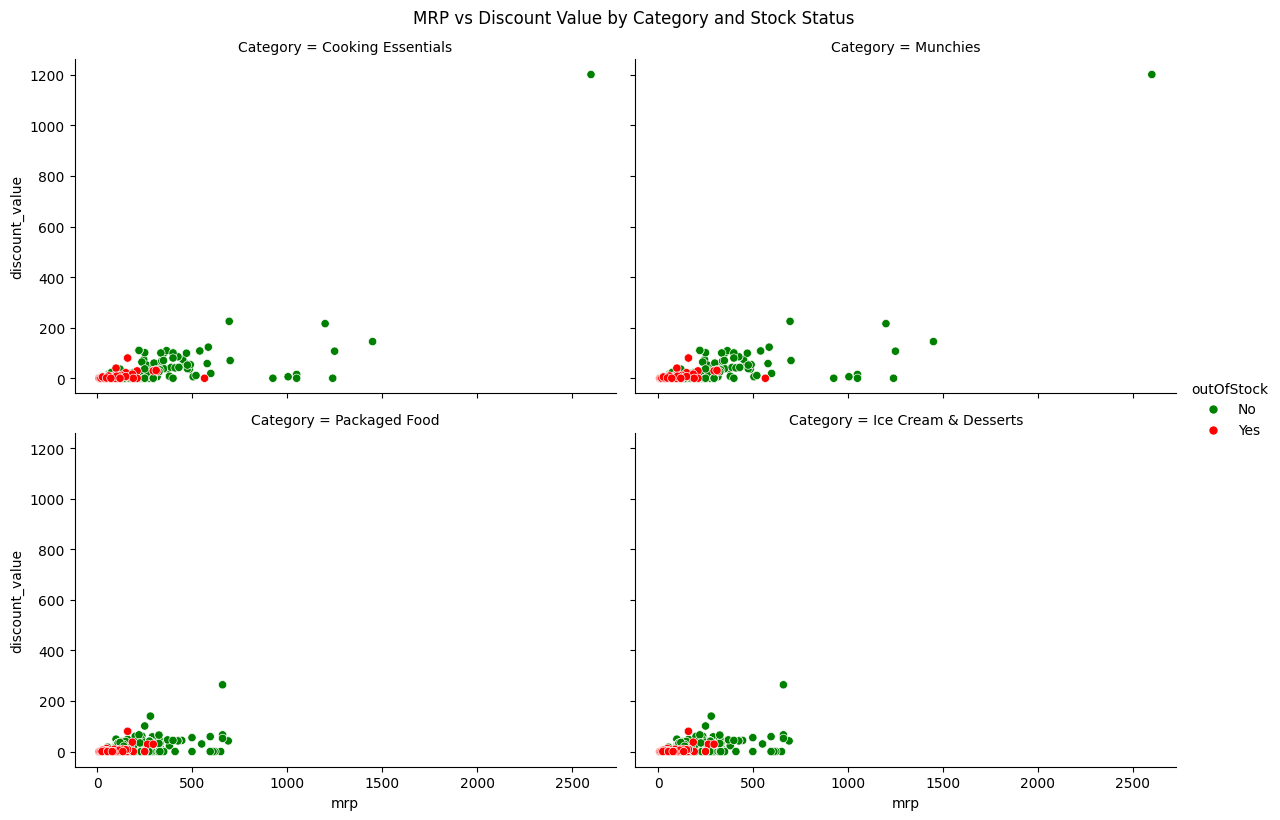

In [ ]:
top_categories = df['Category'].value_counts().head(4).index

sns.relplot(data = df[df['Category'].isin(top_categories)],
            x='mrp', y='discount_value', hue='outOfStock', 
            col='Category', col_wrap=2, height=4, aspect=1.5, palette={'No':'green', 'Yes':'red'})
plt.suptitle('MRP vs Discount Value by Category and Stock Status', y=1.02)
plt.show()

In [26]:
df.columns

Index(['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity'],
      dtype='object')

In [28]:
df.replace({'outOfStock': {'No': 0, 'Yes': 1}}, inplace=True)
corr = df[['discountPercent', 'availableQuantity', 'outOfStock']].corr()

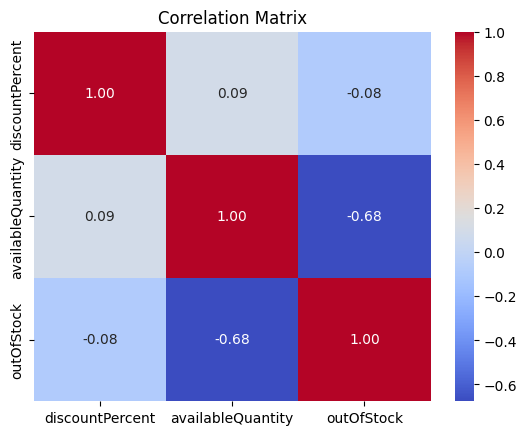

In [29]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## There is no correlation between percentage of discount given and the stock availability of the item.

In [ ]:
# Send this dataframe to mysql
import mysql, sqlalchemy

In [ ]:
from sqlalchemy import create_engine

In [ ]:
username = 'root'
password = 'Kuldeep959'
host = 'localhost'
database = 'zepto_inventory'

engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}/{database}')

In [ ]:
df.to_sql(name='zepto_inventory', con=engine, if_exists='replace', index=False)

3730

## The data is sent to mysql successfully.